您可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和 [Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購 *Think Python 3e* 的印刷版和電子書版本。

In [5]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

# 回傳值

在前面的章節中，我們使用了內建函式（如 `abs` 和 `round`）以及 math 模組中的函式（如 `sqrt` 和 `pow`）。
當您呼叫這些函式時，它們會回傳一個值，您可以將這個值賦給變數或用作表達式的一部分。

到目前為止，我們撰寫的函式都有所不同。
有些使用 `print` 函式來顯示值，有些使用烏龜函式來繪製圖形。
但它們都沒有回傳我們可以賦給變數或在表達式中使用的值。

在這一章中，我們將看到如何撰寫回傳值的函式。

## 有些函式有回傳值

當您呼叫 `math.sqrt` 這樣的函式時，結果稱為**回傳值**。
如果函式呼叫出現在儲存格的末尾，Jupyter 會立即顯示回傳值。

In [6]:
import math

math.sqrt(42 / math.pi)

3.656366395715726

如果您將回傳值賦給變數，就不會顯示出來。

In [7]:
radius = math.sqrt(42 / math.pi)

但您可以稍後顯示它。

In [8]:
radius

3.656366395715726

或者您可以將回傳值用作表達式的一部分。

In [9]:
radius + math.sqrt(42 / math.pi)

7.312732791431452

以下是一個回傳值的函式範例。

In [10]:
def circle_area(radius):
    area = math.pi * radius**2
    return area

`circle_area` 接受 `radius` 作為參數，並計算具有該半徑的圓的面積。

最後一行是 `return` 陳述式，它回傳 `area` 的值。

如果我們像這樣呼叫函式，Jupyter 會顯示回傳值。

In [11]:
circle_area(radius)

42.00000000000001

我們可以將回傳值賦給變數。

In [12]:
a = circle_area(radius)

或將其用作表達式的一部分。

In [13]:
circle_area(radius) + 2 * circle_area(radius / 2)

63.000000000000014

稍後我們可以顯示賦予結果的變數值。

In [14]:
a

42.00000000000001

但我們無法存取 `area`。

In [15]:
%%expect NameError

area

NameError: name 'area' is not defined

`area` 是函式中的區域變數，所以我們無法從函式外部存取它。

## 有些函式回傳 None

如果函式沒有 `return` 陳述式，它會回傳 `None`，這是一個特殊值，就像 `True` 和 `False` 一樣。
例如，這是第3章的 `repeat` 函式。

In [16]:
def repeat(word, n):
    print(word * n)

如果我們像這樣呼叫它，它會顯示蒙提·派森歌曲〈Finland〉的第一行。

In [17]:
repeat('Finland, ', 3)

Finland, Finland, Finland, 


這個函式使用 `print` 函式來顯示字串，但它沒有使用 `return` 陳述式來回傳值。
如果我們將結果賦給變數，它還是會顯示字串。

In [18]:
result = repeat('Finland, ', 3)

Finland, Finland, Finland, 


如果我們顯示變數的值，什麼都沒有。

In [19]:
result

`result` 實際上有一個值，但 Jupyter 不會顯示它。
不過，我們可以像這樣顯示它。

In [20]:
print(result)

None


`repeat` 的回傳值是 `None`。

現在這裡有一個類似於 `repeat` 的函式，但它有回傳值。

In [21]:
def repeat_string(word, n):
    return word * n

請注意，我們可以在 `return` 陳述式中使用表達式，不只是變數。

在這個版本中，我們可以將結果賦給變數。
當函式執行時，它不會顯示任何東西。

In [22]:
line = repeat_string('Spam, ', 4)

但稍後我們可以顯示賦給 `line` 的值。

In [23]:
line

'Spam, Spam, Spam, Spam, '

這樣的函式稱為**純函式**，因為它不顯示任何東西，也沒有任何其他效果，只是回傳一個值。

## 回傳值與條件式

如果 Python 沒有提供 `abs`，我們可以像這樣撰寫它。

In [24]:
def absolute_value(x):
    if x < 0:
        return -x
    else:
        return x

如果 `x` 是負數，第一個 `return` 陳述式回傳 `-x`，函式立即結束。
否則，第二個 `return` 陳述式回傳 `x`，函式結束。
所以這個函式是正確的。

但是，如果您在條件式中放置 `return` 陳述式，您必須確保程式中的每個可能路徑都會執行到 `return` 陳述式。
例如，這裡是 `absolute_value` 的錯誤版本。

In [25]:
def absolute_value_wrong(x):
    if x < 0:
        return -x
    if x > 0:
        return x

如果我們用 `0` 作為引數呼叫這個函式，會發生什麼情況。

In [26]:
absolute_value_wrong(0)

什麼都沒有！問題在於：當 `x` 是 `0` 時，兩個條件都不成立，函式在沒有執行到 `return` 陳述式的情況下結束，這意味著回傳值是 `None`，所以 Jupyter 不顯示任何東西。

另一個例子，這裡是 `absolute_value` 的版本，末尾有額外的 `return` 陳述式。

In [27]:
def absolute_value_extra_return(x):
    if x < 0:
        return -x
    else:
        return x
    
    return 'This is dead code'

如果 `x` 是負數，第一個 `return` 陳述式執行，函式結束。
否則第二個 `return` 陳述式執行，函式結束。
無論如何，我們永遠不會到達第三個 `return` 陳述式，所以它永遠不會執行。

永遠不會執行的程式碼稱為**無效程式碼**。
一般來說，無效程式碼不會造成任何傷害，但它通常表示誤解，可能會讓試圖理解程式的人感到困惑。

## 漸進式開發

當您撰寫更大的函式時，可能會發現自己花更多時間除錯。
為了處理日益複雜的程式，您可能想要嘗試**漸進式開發**，這是一種每次只添加和測試少量程式碼的方法。

舉例來說，假設您想要找到由座標 $(x_1, y_1)$ 和 $(x_2, y_2)$ 表示的兩點之間的距離。
根據畢達哥拉斯定理，距離是：

$$\mathrm{distance} = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$ 

第一步是考慮 `distance` 函式在 Python 中應該是什麼樣子，也就是輸入（參數）和輸出（回傳值）是什麼？

對於這個函式，輸入是點的座標。
回傳值是距離。
您可以立即撰寫函式的大綱：

In [28]:
def distance(x1, y1, x2, y2):
    return 0.0

這個版本還不會計算距離，它總是回傳零。
但它是一個有回傳值的完整函式，這意味著您可以在使其更複雜之前先測試它。

為了測試新函式，我們將用範例引數呼叫它：

In [29]:
distance(1, 2, 4, 6)

0.0

我選擇這些值是因為水平距離是 `3`，垂直距離是 `4`。
這樣，結果是 `5`，即 `3-4-5` 直角三角形的斜邊。測試函式時，知道正確答案是有用的。

到此為止，我們已經確認函式能夠執行並回傳值，我們可以開始在函式本體中添加程式碼。
下一步是找到差值 `x2 - x1` 和 `y2 - y1`。 
這裡是一個將這些值存儲在暫時變數中並顯示它們的版本。

In [30]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    print('dx is', dx)
    print('dy is', dy)
    return 0.0

如果函式正常運作，它應該顯示 `dx is 3` 和 `dy is 4`。
如果是這樣，我們知道函式獲得了正確的引數並正確地執行了第一個計算。如果不是，只需要檢查幾行程式碼。

In [31]:
distance(1, 2, 4, 6)

dx is 3
dy is 4


0.0

到目前為止很好。接下來我們計算 `dx` 和 `dy` 的平方和：

In [32]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    print('dsquared is: ', dsquared)
    return 0.0

再次，我們可以執行函式並檢查輸出，應該是 `25`。

In [33]:
distance(1, 2, 4, 6)

dsquared is:  25


0.0

最後，我們可以使用 `math.sqrt` 來計算距離：

In [34]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    result = math.sqrt(dsquared)
    print("result is", result)

並測試它。

In [35]:
distance(1, 2, 4, 6)

result is 5.0


結果是正確的，但這個版本的函式顯示結果而不是回傳它，所以回傳值是 `None`。

我們可以透過將 `print` 函式替換為 `return` 陳述式來修正這個問題。

In [36]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    result = math.sqrt(dsquared)
    return result

這個版本的 `distance` 是一個純函式。
如果我們像這樣呼叫它，只顯示結果。

In [37]:
distance(1, 2, 4, 6)

5.0

如果我們將結果賦給變數，什麼都不會顯示。

In [38]:
d = distance(1, 2, 4, 6)

我們撰寫的 `print` 陳述式對除錯很有用，但一旦函式正常運作，我們就可以移除它們。 
這樣的程式碼稱為**鷹架程式碼**，因為它有助於建構程式，但不是最終產品的一部分。

這個例子展示了漸進式開發。
這個過程的關鍵面向是：

1.  從可運作的程式開始，進行小的改變，並在每次改變後測試。

2.  使用變數來保存中間值，以便您可以顯示和檢查它們。

3.  一旦程式正常運作，移除鷹架程式碼。

在任何時候，如果有錯誤，您應該很清楚錯誤在哪裡。
漸進式開發可以為您節省大量的除錯時間。

## 布林函式

函式可以回傳布林值 `True` 和 `False`，這對於將複雜的測試封裝在函式中通常很方便。
例如，`is_divisible` 檢查 `x` 是否能被 `y` 整除（沒有餘數）。

In [39]:
def is_divisible(x, y):
    if x % y == 0:
        return True
    else:
        return False

這是我們使用它的方式。

In [40]:
is_divisible(6, 4)

False

In [41]:
is_divisible(6, 3)

True

在函式內部，`==` 運算子的結果是布林值，所以我們可以直接回傳它，讓函式更加簡潔。

In [42]:
def is_divisible(x, y):
    return x % y == 0

布林函式經常用於條件陳述式中。

In [43]:
if is_divisible(6, 2):
    print('divisible')

divisible


您可能會想要撰寫這樣的程式碼：

In [44]:
if is_divisible(6, 2) == True:
    print('divisible')

divisible


但這個比較是不必要的。

## 具有回傳值的遞迴

現在我們可以撰寫具有回傳值的函式，我們也可以撰寫具有回傳值的遞迴函式，有了這個能力，我們已經跨越了一個重要的門檻──我們擁有的 Python 子集現在是**圖靈完備**的，這意味著我們可以執行任何可以用演算法描述的計算。

為了展示具有回傳值的遞迴，我們將評估一些遞迴定義的數學函式。
遞迴定義類似於循環定義，在某種意義上，定義會引用正在定義的事物。真正的循環定義並不是很有用：

> vorpal：用來描述某種 vorpal 的形容詞。

如果您在字典中看到這個定義，您可能會感到惱火。 
另一方面，如果您查詢階乘函式的定義，用符號 $!$ 表示，您可能會得到這樣的內容： 

$$\begin{aligned}
0! &= 1 \\
n! &= n~(n-1)!
\end{aligned}$$ 

這個定義說 $0$ 的階乘是 $1$，任何其他值 $n$ 的階乘是 $n$ 乘以 $n-1$ 的階乘。

如果您可以撰寫某樣東西的遞迴定義，您就可以撰寫 Python 程式來評估它。 
遵循漸進式開發過程，我們將從一個接受 `n` 作為參數並總是回傳 `0` 的函式開始。

In [45]:
def factorial(n):
    return 0

現在讓我們加入定義的第一部分──如果引數恰好是 `0`，我們只需要回傳 `1`：

In [46]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return 0

現在讓我們填入第二部分──如果 `n` 不是 `0`，我們必須進行遞迴呼叫來找到 `n-1` 的階乘，然後將結果乘以 `n`：

In [47]:
def factorial(n):
    if n == 0:
        return 1
    else:
        recurse = factorial(n-1)
        return n * recurse

這個程式的執行流程類似於第5章中 `countdown` 的流程。
如果我們用值 `3` 呼叫 `factorial`：

由於 `3` 不是 `0`，我們進入第二個分支並計算
`n-1` 的階乘...

> 由於 `2` 不是 `0`，我們進入第二個分支並計算
> `n-1` 的階乘...
>
> > 由於 `1` 不是 `0`，我們進入第二個分支並計算
> > `n-1` 的階乘...
> >
> > > 由於 `0` 等於 `0`，我們進入第一個分支並回傳 `1`，
> > > 不進行任何更多的遞迴呼叫。
> >
> > 回傳值 `1` 乘以 `n`（即 `1`），結果被回傳。
>
> 回傳值 `1` 乘以 `n`（即 `2`），結果被回傳。

回傳值 `2` 乘以 `n`（即 `3`），結果 `6` 成為開始整個過程的函式呼叫的回傳值。

下圖顯示了這一系列函式呼叫的堆疊圖。

In [48]:
from diagram import Frame, Stack, make_binding

main = Frame([], name='__main__', loc='left')
frames = [main]

ns = 3, 2, 1
recurses = 2, 1, 1
results = 6, 2, 1

for n, recurse, result in zip(ns, recurses, results):
    binding1 = make_binding('n', n)
    binding2 = make_binding('recurse', recurse)
    frame = Frame([binding1, binding2], 
                  name='factorial', value=result,
                  loc='left', dx=1.2)
    frames.append(frame)
    
binding1 = make_binding('n', 0)
frame = Frame([binding1], name='factorial', value=1, 
              shim=1.2, loc='left', dx=1.4)
frames.append(frame)

stack = Stack(frames, dy=-0.45)

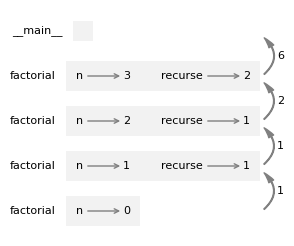

In [49]:
from diagram import diagram, adjust

width, height, x, y = [2.74, 2.26, 0.73, 2.05]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

回傳值顯示傳遞回堆疊的上層。
在每個框架中，回傳值是 `n` 和 `recurse` 的乘積。

在最後一個框架中，區域變數 `recurse` 不存在，因為建立它的分支沒有執行。

## 信念的跳躍

追蹤執行流程是閱讀程式的一種方式，但很快就會變得難以應付。另一種方式是我稱之為「信念的跳躍」。當您遇到函式呼叫時，不要追蹤執行流程，而是*假設*函式正確運作並回傳正確的結果。

事實上，當您使用內建函式時，您已經在實踐這種信念的跳躍。
當您呼叫 `abs` 或 `math.sqrt` 時，您不會檢查這些函式的內容，您只是假設它們有效。

當您呼叫自己的函式時也是如此。例如，之前我們撰寫了一個名為 `is_divisible` 的函式，用來判斷一個數字是否能被另一個數字整除。一旦我們確信這個函式是正確的，我們就可以使用它而不需要再次查看內容。

遞迴程式也是如此。
當您到達遞迴呼叫時，不要追蹤執行流程，您應該假設遞迴呼叫有效，然後問自己：「假設我可以計算 $n-1$ 的階乘，我能計算 $n$ 的階乘嗎？」
階乘的遞迴定義暗示您可以，透過乘以 $n$。

當然，在您還沒有完成函式撰寫時就假設函式正確運作有點奇怪，但這就是為什麼它被稱為信念的跳躍！

## 費氏數列

在 `factorial` 之後，遞迴函式最常見的例子是 `fibonacci`，它有以下定義： 

$$\begin{aligned}
\mathrm{fibonacci}(0) &= 0 \\
\mathrm{fibonacci}(1) &= 1 \\
\mathrm{fibonacci}(n) &= \mathrm{fibonacci}(n-1) + \mathrm{fibonacci}(n-2)
\end{aligned}$$ 

翻譯成 Python，看起來像這樣：

In [50]:
def fibonacci(n):
    if n == 0:
        return 0
    elif  n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

如果您試圖在這裡追蹤執行流程，即使對於 $n$ 的小值，您的頭也會爆炸。
但根據信念的跳躍，如果您假設兩個遞迴呼叫正確運作，您可以確信最後的 `return` 陳述式是正確的。

順帶一提，這種計算費氏數列的方法非常沒有效率。
在[第10章](section_memos)中，我將解釋原因並建議改進的方法。

## 檢查類型

如果我們呼叫 `factorial` 並給它 `1.5` 作為引數會發生什麼？

In [51]:
%%expect RecursionError

factorial(1.5)

RecursionError: maximum recursion depth exceeded in comparison

看起來像無限遞迴。怎麼可能？函式有基本情況，當 `n == 1` 或 `n == 0` 時。
但如果 `n` 不是整數，我們可能會*錯過*基本情況並永遠遞迴下去。

在這個例子中，`n` 的初始值是 `1.5`。
在第一次遞迴呼叫中，`n` 的值是 `0.5`。
在下一次中，是 `-0.5`。 
從那裡開始，它變得更小（更負），但永遠不會是 `0`。

為了避免無限遞迴，我們可以使用內建函式 `isinstance` 來檢查引數的類型。
這裡是我們檢查值是否為整數的方法。

In [52]:
isinstance(3, int)

True

In [53]:
isinstance(1.5, int)

False

現在這裡是有錯誤檢查的 `factorial` 版本。

In [54]:
def factorial(n):
    if not isinstance(n, int):
        print('factorial is only defined for integers.')
        return None
    elif n < 0:
        print('factorial is not defined for negative numbers.')
        return None
    elif n == 0:
        return 1
    else:
        return n * factorial(n-1)

首先它檢查 `n` 是否為整數。
如果不是，它顯示錯誤訊息並回傳 `None`。

In [55]:
factorial('crunchy frog')

factorial is only defined for integers.


然後它檢查 `n` 是否為負數。
如果是，它顯示錯誤訊息並回傳 `None`。

In [56]:
factorial(-2)

factorial is not defined for negative numbers.


如果我們通過兩個檢查，我們知道 `n` 是非負整數，所以我們可以確信遞迴會終止。
檢查函式的參數以確保它們具有正確的類型和值稱為**輸入驗證**。

## 除錯

將大型程式分解為較小的函式為除錯創造了自然的檢查點。
如果函式不運作，有三種可能性需要考慮：

-   函式獲得的引數有問題，也就是違反了前提條件。

-   函式有問題，也就是違反了後置條件。

-   呼叫者對回傳值的處理有問題。

為了排除第一種可能性，您可以在函式開頭添加 `print` 陳述式來顯示參數的值（以及可能的類型）。
或者您可以撰寫明確檢查前提條件的程式碼。

如果參數看起來正常，您可以在每個 `return` 陳述式之前添加 `print` 陳述式並顯示回傳值。
如果可能的話，用容易檢查結果的引數呼叫函式。 

如果函式似乎運作正常，查看函式呼叫以確保回傳值被正確使用，或者完全被使用！

在函式的開頭和結尾添加 `print` 陳述式可以幫助使執行流程更加清晰。
例如，這裡是有 print 陳述式的 `factorial` 版本：

In [57]:
def factorial(n):
    space = ' ' * (4 * n)
    print(space, 'factorial', n)
    if n == 0:
        print(space, 'returning 1')
        return 1
    else:
        recurse = factorial(n-1)
        result = n * recurse
        print(space, 'returning', result)
        return result

`space` 是一個空格字符字串，控制輸出的縮排。這裡是 `factorial(3)` 的結果：

In [58]:
factorial(3)

             factorial 3
         factorial 2
     factorial 1
 factorial 0
 returning 1
     returning 1
         returning 2
             returning 6


6

如果您對執行流程感到困惑，這種輸出會很有幫助。
開發有效的鷹架程式碼需要一些時間，但一點點鷹架程式碼可以節省大量的除錯時間。

## 詞彙表

**回傳值：**
函式的結果。如果函式呼叫用作表達式，回傳值就是表達式的值。

**純函式：**
除了回傳一個回傳值之外，不顯示任何東西或產生任何其他效果的函式。

**無效程式碼：**
程式中永遠不會執行的部分，通常因為它出現在 `return` 陳述式之後。

**漸進式開發：**
一種程式開發計劃，旨在透過每次只添加和測試少量程式碼來避免除錯。

**鷹架程式碼：**
 程式開發期間使用但不是最終版本一部分的程式碼。

**圖靈完備：**
一種語言或語言的子集，如果它可以執行任何可以用演算法描述的計算，就是圖靈完備的。

**輸入驗證：**
檢查函式的參數以確保它們具有正確的類型和值。

## 練習

In [59]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### 請教虛擬助理

在本章中，我們看到一個可能會在沒有回傳值的情況下結束的錯誤函式。

In [60]:
def absolute_value_wrong(x):
    if x < 0:
        return -x
    if x > 0:
        return x

以及同一個函式的版本，在末尾有無效程式碼。

In [61]:
def absolute_value_extra_return(x):
    if x < 0:
        return -x
    else:
        return x
    
    return 'This is dead code.'

我們也看到了以下例子，它是正確的但不夠慣用。

In [62]:
def is_divisible(x, y):
    if x % y == 0:
        return True
    else:
        return False

請教虛擬助理這些函式有什麼問題，看看它是否能發現錯誤或改進風格。

然後問「撰寫一個函式，接受兩個點的座標並計算它們之間的距離。」看看結果是否類似於我們在本章中撰寫的 `distance` 版本。

### 練習

使用漸進式開發來撰寫一個名為 `hypot` 的函式，該函式回傳直角三角形斜邊的長度，給定其他兩條邊的長度作為引數。

注意：math 模組中有一個名為 `hypot` 的函式可以做同樣的事情，但您不應該在這個練習中使用它！

即使您可以在第一次嘗試時正確撰寫函式，也要從總是回傳 `0` 的函式開始，並練習進行小的改變，邊改邊測試。
完成後，函式應該只回傳一個值，不應該顯示任何東西。

In [63]:
# Solution

def hypot(a, b):
    return 0

In [64]:
# Solution

hypot(3, 4)

0

In [65]:
# Solution

def hypot(a, b):
    d2 = a**2 + b**2
    print(d2)
    return 0

In [66]:
# Solution

hypot(3, 4)

25


0

In [67]:
# Solution

def hypot(a, b):
    d2 = a**2 + b**2
    result = math.sqrt(d2)
    print(result)
    return 0

In [68]:
# Solution

hypot(3, 4)

5.0


0

In [69]:
# Solution

def hypot(a, b):
    d2 = a**2 + b**2
    result = math.sqrt(d2)
    return result

In [70]:
# Solution

hypot(3, 4)

5.0

In [71]:
# Solution

def hypotenuse(a, b):
    return math.sqrt(a**2 + b**2)

In [72]:
# Solution

hypot(3, 4)

5.0

### 練習

撰寫一個布林函式 `is_between(x, y, z)`，如果 $x < y < z$ 或 
$z < y < x$ 則回傳 `True`，否則回傳 `False`。

In [73]:
# Solution

def is_between(x, y, z):
    if x < y < z:
        return True
    else:
        return z < y < x

您可以使用這些例子來測試您的函式。

In [74]:
is_between(1, 2, 3)  # should be True

True

In [75]:
is_between(3, 2, 1)  # should be True

True

In [76]:
is_between(1, 3, 2)  # should be False

False

In [77]:
is_between(2, 3, 1)  # should be False

False

### 練習

阿克曼函式 $A(m, n)$ 定義為：

$$\begin{aligned}
A(m, n) = \begin{cases} 
              n+1 & \mbox{如果 } m = 0 \\ 
        A(m-1, 1) & \mbox{如果 } m > 0 \mbox{ 且 } n = 0 \\ 
A(m-1, A(m, n-1)) & \mbox{如果 } m > 0 \mbox{ 且 } n > 0.
\end{cases} 
\end{aligned}$$ 

撰寫一個名為 `ackermann` 的函式來評估阿克曼函式。
如果您呼叫 `ackermann(5, 5)` 會發生什麼？

In [78]:
# Solution

def ackermann(m, n):
    """Computes the Ackermann function A(m, n)

    See http://en.wikipedia.org/wiki/Ackermann_function

    n, m: non-negative integers
    """
    if m == 0:
        return n+1
    if n == 0:
        return ackermann(m-1, 1)
    return ackermann(m-1, ackermann(m, n-1))

您可以使用這些例子來測試您的函式。

In [79]:
ackermann(3, 2)  # should be 29

29

In [80]:
ackermann(3, 3)  # should be 61

61

In [81]:
ackermann(3, 4)  # should be 125

125

如果您用大於 4 的值呼叫這個函式，您會得到 `RecursionError`。

In [82]:
%%expect RecursionError

ackermann(5, 5)

RecursionError: maximum recursion depth exceeded in comparison

要了解原因，請在函式開頭添加 print 陳述式來顯示參數的值，然後再次執行範例。

### 練習

數字 $a$ 是 $b$ 的冪，如果它能被 $b$ 整除且 $a/b$ 是 $b$ 的冪。撰寫一個名為 `is_power` 的函式，接受參數 `a` 和 `b`，如果 `a` 是 `b` 的冪則回傳 `True`。注意：您需要考慮基本情況。

In [83]:
# Solution

def is_power(a, b):
    """Check whether a is a power of b
    """
    if a == 1:
        return True
    
    if is_divisible(a, b):
        return is_power(a/b, b)
    else:
        return False

您可以使用這些例子來測試您的函式。

In [84]:
is_power(65536, 2)   # should be True

True

In [85]:
is_power(27, 3)  # should be True

True

In [86]:
is_power(24, 2)  # should be False

False

In [87]:
is_power(1, 17)   # should be True

True

### 練習

$a$ 和 $b$ 的最大公因數（GCD）是能同時整除兩者且沒有餘數的最大數字。

找到兩個數字的 GCD 的一種方法基於這樣的觀察：如果 $r$ 是 $a$ 除以 $b$ 的餘數，那麼 $gcd(a, b) = gcd(b, r)$。作為基本情況，我們可以使用 $gcd(a, 0) = a$。

撰寫一個名為 `gcd` 的函式，接受參數 `a` 和 `b` 並回傳它們的最大公因數。

In [88]:
# Solution

def gcd(a, b):
    if b == 0:
        return a
    else:
        return gcd(b, a%b)

您可以使用這些例子來測試您的函式。

In [89]:
gcd(12, 8)    # should be 4

4

In [90]:
gcd(13, 17)   # should be 1

1

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

版權所有 2024 [Allen B. Downey](https://allendowney.com)

程式碼授權：[MIT License](https://mit-license.org/)

文字授權：[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)